In [3]:
import tensorflow as tf
s=tf.constant(36.6)
s

<tf.Tensor: shape=(), dtype=float32, numpy=36.599998474121094>

In [4]:
v=tf.constant([255,128,0])
v

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([255, 128,   0], dtype=int32)>

In [5]:
m=tf.constant([[1.0,2.0],
              [3.0,4.0]])
m

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 2.],
       [3., 4.]], dtype=float32)>

In [6]:
print("shape:",m.shape, "dtype:",m.dtype ,"rank:",tf.rank(m).numpy())

shape: (2, 2) dtype: <dtype: 'float32'> rank: 2


In [7]:
x=tf.Variable(3.0)
x

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.0>

In [8]:
print("zeros:\n",tf.zeros((2,3)).numpy())
print("ones:\n",tf.ones((2,3)).numpy())
print("random normal:\n",tf.random.normal((2,2)).numpy())
print("range:",tf.range(0,10,2).numpy())


zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
random normal:
 [[ 0.5648434   1.5274669 ]
 [-0.86794144  0.6777758 ]]
range: [0 2 4 6 8]


In [9]:
import numpy as np
arr=np.array([[1.0,2.0],
              [3.0,4.0]])
t=tf.constant(arr)
t

<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
array([[1., 2.],
       [3., 4.]])>

In [10]:
back=t.numpy()
back

array([[1., 2.],
       [3., 4.]])

In [11]:
a=tf.constant([3,3,3])
b=tf.constant([2,2,2])

(a+b).numpy()

array([5, 5, 5], dtype=int32)

In [12]:
(a-b).numpy()

array([1, 1, 1], dtype=int32)

In [13]:
(a*b).numpy()

array([6, 6, 6], dtype=int32)

In [14]:
(a/b).numpy()

array([1.5, 1.5, 1.5])

In [15]:
tf.reduce_sum(a)

<tf.Tensor: shape=(), dtype=int32, numpy=9>

In [16]:
tf.reduce_mean(a)

<tf.Tensor: shape=(), dtype=int32, numpy=3>

In [17]:
A=tf.constant([[1.0,2.0],[3.0,4.0]])
B=tf.constant([[0.5,-1],[1.0,2.0]])
print("element wise\n:",(A*B).numpy())#cell by cell
print("matrix multiplication:\n",(A@B).numpy())


element wise
: [[ 0.5 -2. ]
 [ 3.   8. ]]
matrix multiplication:
 [[2.5 3. ]
 [5.5 5. ]]


In [18]:
a=tf.constant([1.0,2.0,3.0])
print((a+10).numpy())

[11. 12. 13.]


In [19]:
M=tf.constant([1.0,2.0,3.0])
rows=tf.ones((3,3))
print("row added to every row of M:\n",(M+rows).numpy())

row added to every row of M:
 [[2. 3. 4.]
 [2. 3. 4.]
 [2. 3. 4.]]


In [20]:
inputs=tf.constant([[1.0,2.0],[3.0,4.0]])#(2 samples,2 features)
weights=tf.constant([[0.5,-1],[1.0,2.0]])#(2 features,2 units)
layer_output=tf.matmul(inputs,weights)
print(layer_output.numpy())

[[2.5 3. ]
 [5.5 5. ]]


In [21]:
a=tf.constant(5.0)
b=tf.constant(10.0)
x=tf.Variable(3.0)
print("a*x+b=",(a*x+b).numpy())
x.assign(4.0)
print("after assign x=4.0:",(a*x+b).numpy())

a*x+b= 25.0
after assign x=4.0: 30.0


In [22]:
x=tf.Variable(3.0)

with tf.GradientTape() as tape:
  y=x**2+2*x+1

dy_dx=tape.gradient(y,x)
print(dy_dx.numpy())

8.0


In [23]:
#toy linear model y_pred=m*x+b,fit to y_true=10

w=tf.Variable(1.0)
b=tf.Variable(0.0)
x=tf.constant(2.0)
y_true=tf.constant(10.0)
lr=0.01#learning rate

for step in range(50):
 with tf.GradientTape() as tape:
   y_pred=w*x+b
   loss=(y_true-y_pred)**2#squarred error

 grad_w,grad_b=tape.gradient(loss,[w,b])#gradient for both at once
 w.assign_sub(lr*grad_w)#gradient descent step
 b.assign_sub(lr*grad_b)

print("learned w:",w.numpy(),"b:",b.numpy(),"final loss:",loss.numpy())

learned w: 4.1835074 b: 1.5917542 final loss: 0.002098795


creating a neural network from scratch

In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

class Perceptron:
  def __init__(self,learning_rate=0.1,epochs=10):
    self.learning_rate=learning_rate
    self.epochs=epochs
    self.weights=None
    self.bias=None

  def activation(self,z):
    return 1 if z>=0 else 0

  def predict(self,inputs):
    return self.activation(np.dot(inputs,self.weights)+self.bias)

  def fit(self,X,y):
    self.weights=np.random.rand(X.shape[1])
    self.bias=np.random.rand(1)
    for _ in range(self.epochs):
      for inputs,target in zip(X,y):
        error=target-self.predict(inputs)
        self.weights+=self.learning_rate*error*inputs
        self.bias+=self.learning_rate*error

iris=load_iris()
X=iris.data[:,:2]
y=np.where(iris.target!=0,0,1)#setosa=1 else 0

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

clf=Perceptron(learning_rate=0.1,epochs=10)
clf.fit(X_train,y_train)

y_pred=np.array([clf.predict(x) for x in X_test])
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.92      0.95      0.93        30
weighted avg       0.94      0.93      0.93        30



In [25]:
def sigmoid(x):return 1/(1+np.exp(-x))
def relu(x):return np.maximum(0,x)
def tanh(x):return np.tanh(x)

x=np.array([-1.0,0.0,1.0,2.0])
print("sigmoid:",sigmoid(x))
print("relu:",relu(x))
print("tanh:",tanh(x))

sigmoid: [0.26894142 0.5        0.73105858 0.88079708]
relu: [0. 0. 1. 2.]
tanh: [-0.76159416  0.          0.76159416  0.96402758]


In [26]:
from tensorflow import keras
from keras import layers,Input
model=keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
inputs=keras.Input(shape=(2,))
x=layers.Dense(8,activation="relu")(inputs)
outputs=layers.Dense(1,activation="sigmoid")(x)
functionnal_model=keras.Model(inputs=inputs,outputs=outputs)
functionnal_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
tf.random.set_seed(42)
fashion_mnist=keras.datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()
class_names=['T-shirt/top','Trouser','Pullover',
             'Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print("train shape:",train_images.shape," test shape:",test_images.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train shape: (60000, 28, 28)  test shape: (10000, 28, 28)


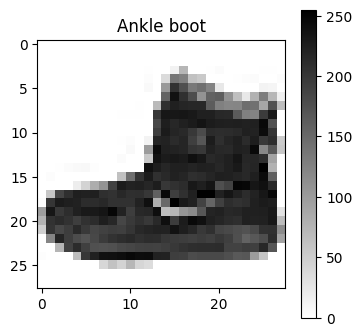

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(train_images[0],cmap="binary")
plt.title(class_names[train_labels[0]])
plt.colorbar()
plt.grid(False)
plt.show()

In [30]:
#normalize both sets identically
train_images=train_images/255.0
test_images=test_images/255.0

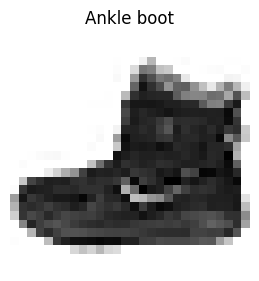

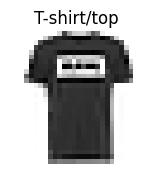

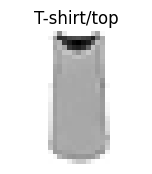

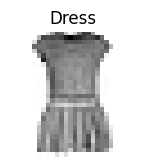

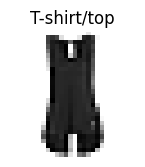

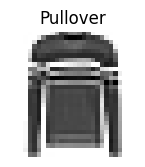

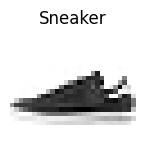

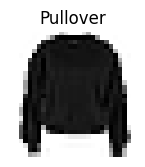

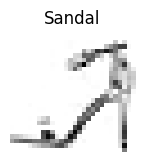

In [31]:
plt.figure(figsize=(8,8))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(train_images[i],cmap="binary")
  plt.title(class_names[train_labels[i]])
  plt.axis("off")
  plt.tight_layout()
  plt.show()

In [32]:
#build the model
model=keras.Sequential([
   keras.Input(shape=(28,28)),#28*28=784-vector(size of image)
   layers.Flatten(),
   layers.Dense(128,activation='relu'), (128 neurons)
   layers.Dense(10)           #row logits(no softmax here)
])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
#compile the model
model.compile(optimizer="adam",
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])

In [34]:
#train with validation + early stopping
callbacks=[keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]

history=model.fit(
    train_images,train_labels,
    validation_split=0.1,
    verbose=1,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8201 - loss: 0.5101 - val_accuracy: 0.8537 - val_loss: 0.4053
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8619 - loss: 0.3823 - val_accuracy: 0.8633 - val_loss: 0.3676
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8750 - loss: 0.3411 - val_accuracy: 0.8682 - val_loss: 0.3536
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8847 - loss: 0.3151 - val_accuracy: 0.8715 - val_loss: 0.3519
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8912 - loss: 0.2958 - val_accuracy: 0.8765 - val_loss: 0.3410
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8966 - loss: 0.2797 - val_accuracy: 0.8793 - val_loss: 0.3335
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9019 - loss: 0.2657 - val_accuracy: 0.8787 - val_loss: 0.3449
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9066 - loss: 0.2534 -

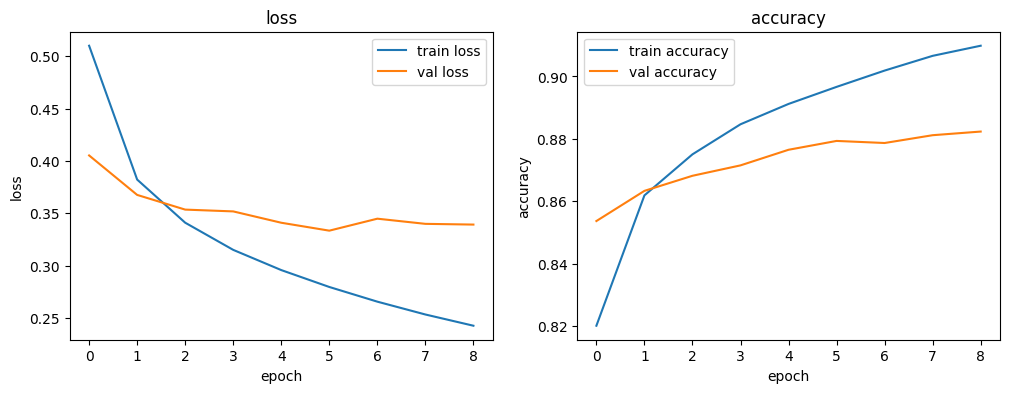

In [38]:
#reading the curves,spotting overfitting live
def plot_history(history):
  fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
  ax1.plot(history.history['loss'],label='train loss')
  if 'val_loss' in history.history:
      ax1.plot(history.history['val_loss'],label='val loss')
  ax1.set_xlabel('epoch')
  ax1.set_ylabel('loss')
  ax1.legend()
  ax1.set_title('loss')

  ax2.plot(history.history['accuracy'],label='train accuracy')
  if 'val_accuracy' in history.history:
      ax2.plot(history.history['val_accuracy'],label='val accuracy')
  ax2.set_xlabel('epoch')
  ax2.set_ylabel('accuracy')
  ax2.legend()
  ax2.set_title('accuracy')
  plt.show()

plot_history(history)


In [40]:
#evaluate on test dataset
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=2)
print("test accuracy:",test_acc)

313/313 - 2s - 5ms/step - accuracy: 0.8754 - loss: 0.3593
test accuracy: 0.8754000067710876


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


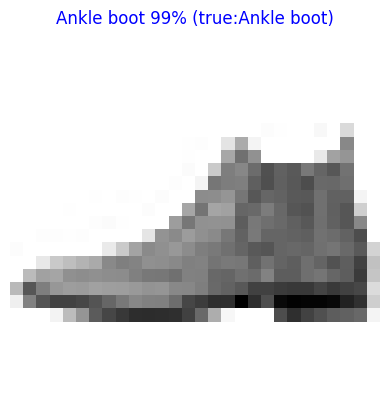

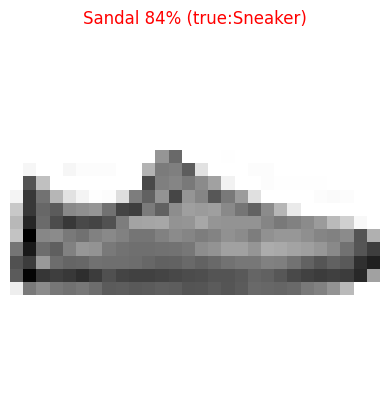

In [42]:
#predict on new data
#since our model outputs logits, we attach a softmax layer to read probabilities
probability_model=keras.Sequential([model,keras.layers.Softmax()])
predictions=probability_model.predict(test_images)

def show_prediction(i):
  probs=predictions[i]
  guess,truth=np.argmax(probs),test_labels[i]
  color="blue" if guess==truth else "red"
  plt.imshow(test_images[i],cmap="binary")
  plt.title(f"{class_names[guess]} {100*probs.max():.0f}% (true:{class_names[truth]})",
            color=color)
  plt.axis("off")
  plt.show()

show_prediction(0)
show_prediction(12)


In [44]:
#prediction on a single image the right way not the batch dimension
single=test_images[0]#shape(28,28)
single_batch=np.expand_dims(single,axis=0)#shape(1,28,28)->the fix
probs=probability_model.predict(single_batch)
print(f"predicted class:",np.argmax(probs[0]),"name:",class_names[np.argmax(probs[0])],
      "confidence:",probs[0].max())


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
predicted class: 9 name: Ankle boot confidence: 0.990352


In [45]:
#save the model
model.save("fashion_mnist.keras")#architecture+weights+optimizer
reloaded=keras.models.load_model("fashion_mnist.keras")
loss2,acc2=reloaded.evaluate(test_images,test_labels,verbose=0)
print("reloaded accuracy:",acc2)

reloaded accuracy: 0.8754000067710876
